# T47 — Sediment-hosted Cu deposits on reconstructed paleo-Earth

**Sediment-hosted copper plays a major economic role.** The Central African Copperbelt (Zambia + DRC), the European Kupferschiefer (Poland, Germany), the Russian Udokan deposit, the Dzhezkazgan district (Kazakhstan), the Midcontinent Rift Cu province (USA), the Bolivian Corocoro, and the Indian Khetri belt are all intracontinental sediment-hosted Cu, formed in cratonic basins far from any active arc. This notebook reconstructs eighteen major sediment-hosted Cu deposits to their host-formation ages, overlays them on the contemporaneous paleo-Earth at three representative ages, and contrasts the resulting paleo-tectonic setting against the arc-related porphyry-Cu distribution of T44/T45.

## What this notebook produces

(i) A reconstructed paleo-Earth map at 880 Ma showing the Central African Copperbelt clustering on the Congo Craton inside the Lufilian arc paleo-basin, alongside the contemporaneous Udokan deposit on the Siberian Craton; (ii) a Permian (~260 Ma) snapshot showing the European Kupferschiefer at the south margin of the Zechstein Sea; (iii) a Proterozoic (~1.7 Ga) snapshot showing the Mt Isa-style and White Pine Midcontinent Rift Cu camps. The contrast with the porphyry-Cu envelope of T45 is the key teaching point.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.

## Learning objectives

- Recognise that "Cu paleo-prospectivity" is not synonymous with "subduction zone proximity" — major Cu provinces formed in cratonic basins.
- Reconstruct each major sediment-hosted Cu district to its host-formation age and verify the paleo-tectonic setting is non-arc.
- Pair this notebook with T44/T45 to teach the porphyry-versus-sediment-hosted dichotomy in reconstruction-aware terms.

## Prerequisites and runtime

- **Plate model**: Müller 2022 (1 Ga coverage) for the Proterozoic-Phanerozoic deposits; falls back to Cao 2024 for the deepest-time deposits.
- **Data**: `data/sediment_hosted_cu/sediment_hosted_cu.csv` — 18 major districts.
- **Python**: `gplately`, `pygmt`, `pygplates`, `pandas`, `numpy`.
- **Runtime**: ~1 minute.

## Data availability

This notebook reads the bundled `data/sediment_hosted_cu/sediment_hosted_cu.csv`. The 18 entries are the canonical major sediment-hosted Cu districts. For exhaustive compilations:

- **Hitzman et al. (2010)**: *Economic Geology* 100th Anniversary Volume — comprehensive review.
- **Brown et al. (2014)**: IAGOD Mineral Deposit Database — global catalog.
- **USGS Mineral Resources Data System**: searchable global database — `https://mrdata.usgs.gov/mrds/`.

In [11]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from pathlib import Path
from IPython.display import display, HTML

# Library versions (printed for reproducibility)
try:
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

In [12]:
# === USER CONFIGURATION =====================================================
DEPOSITS_CSV   = "data/sediment_hosted_cu/sediment_hosted_cu.csv"
MODEL_NAME     = "Cao2024"
ANCHOR_PLATE_ID = 0
# One snapshot per major Cu epoch represented in the bundled compilation.
# Cao 2024 covers the full 0-1800 Ma window, so even the deepest-time
# deposits (Mt Isa-style 1640-1670 Ma, Udokan 1860 Ma) have plate
# boundaries on their reconstructed paleo-Earth.
SNAPSHOT_TIMES = (30.0, 260.0, 305.0, 880.0, 1075.0, 1660.0, 1800.0)
# ============================================================================


## 1. Load major sediment-hosted Cu districts

In [13]:
# Cell 2 — load
dep = pd.read_csv(DEPOSITS_CSV, comment="#")
dep.columns = [c.strip() for c in dep.columns]
print(f"  loaded {len(dep)} districts spanning {dep.age_ma.min():.0f}–{dep.age_ma.max():.0f} Ma")
print(dep.groupby("country").size())


  loaded 18 districts spanning 30–1860 Ma
country
Australia     2
Bolivia       1
DRC           3
Germany       2
India         1
Kazakhstan    1
Poland        2
Russia        1
USA           2
Zambia        3
dtype: int64


## 2. Reconstruct each district to its host-formation age

In [14]:
# Cell 3 — per-district paleo-positions
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons())

paleo_lons, paleo_lats = [], []
for _, row in dep.iterrows():
    pt = gplately.Points(recon, [row["lon"]], [row["lat"]])
    rlon, rlat = pt.reconstruct(float(row["age_ma"]), return_array=True)
    paleo_lons.append(float(rlon[0])); paleo_lats.append(float(rlat[0]))
dep["paleo_lon"] = paleo_lons
dep["paleo_lat"] = paleo_lats


## 3. Per-age paleo-Earth maps

  30 Ma  window -70-130 Ma  -> 1 deposits (['Red-bed Cu'])


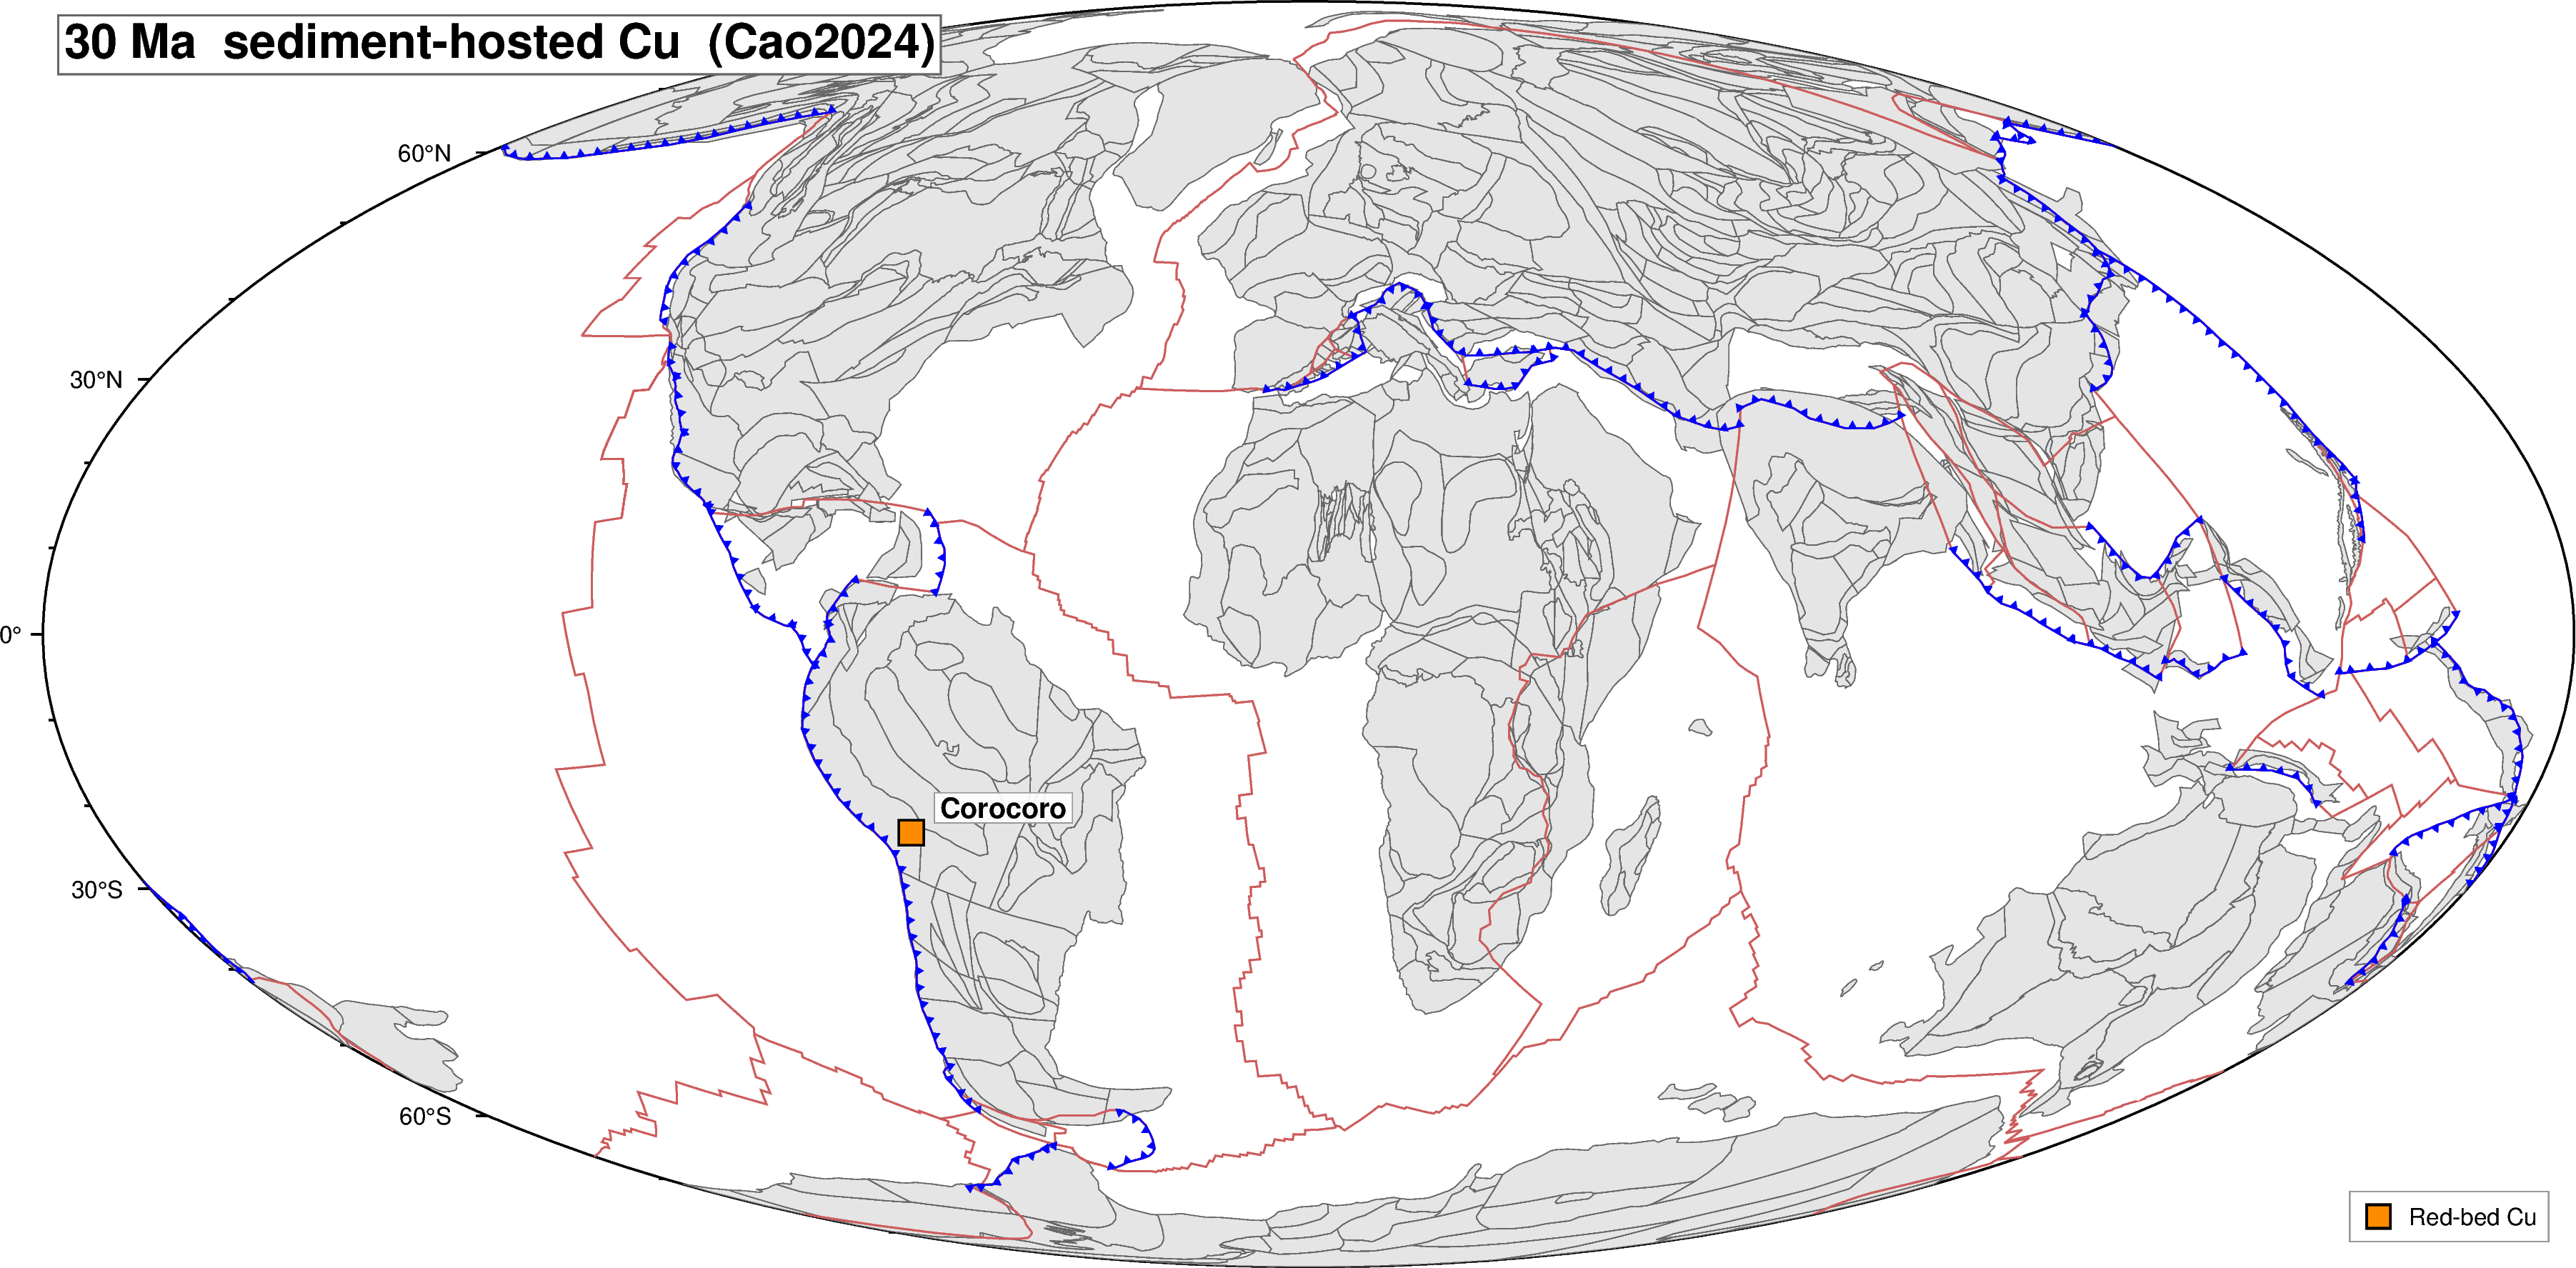

  260 Ma  window 160-360 Ma  -> 5 deposits (['Red-bed Cu', 'SSC reduced facies'])


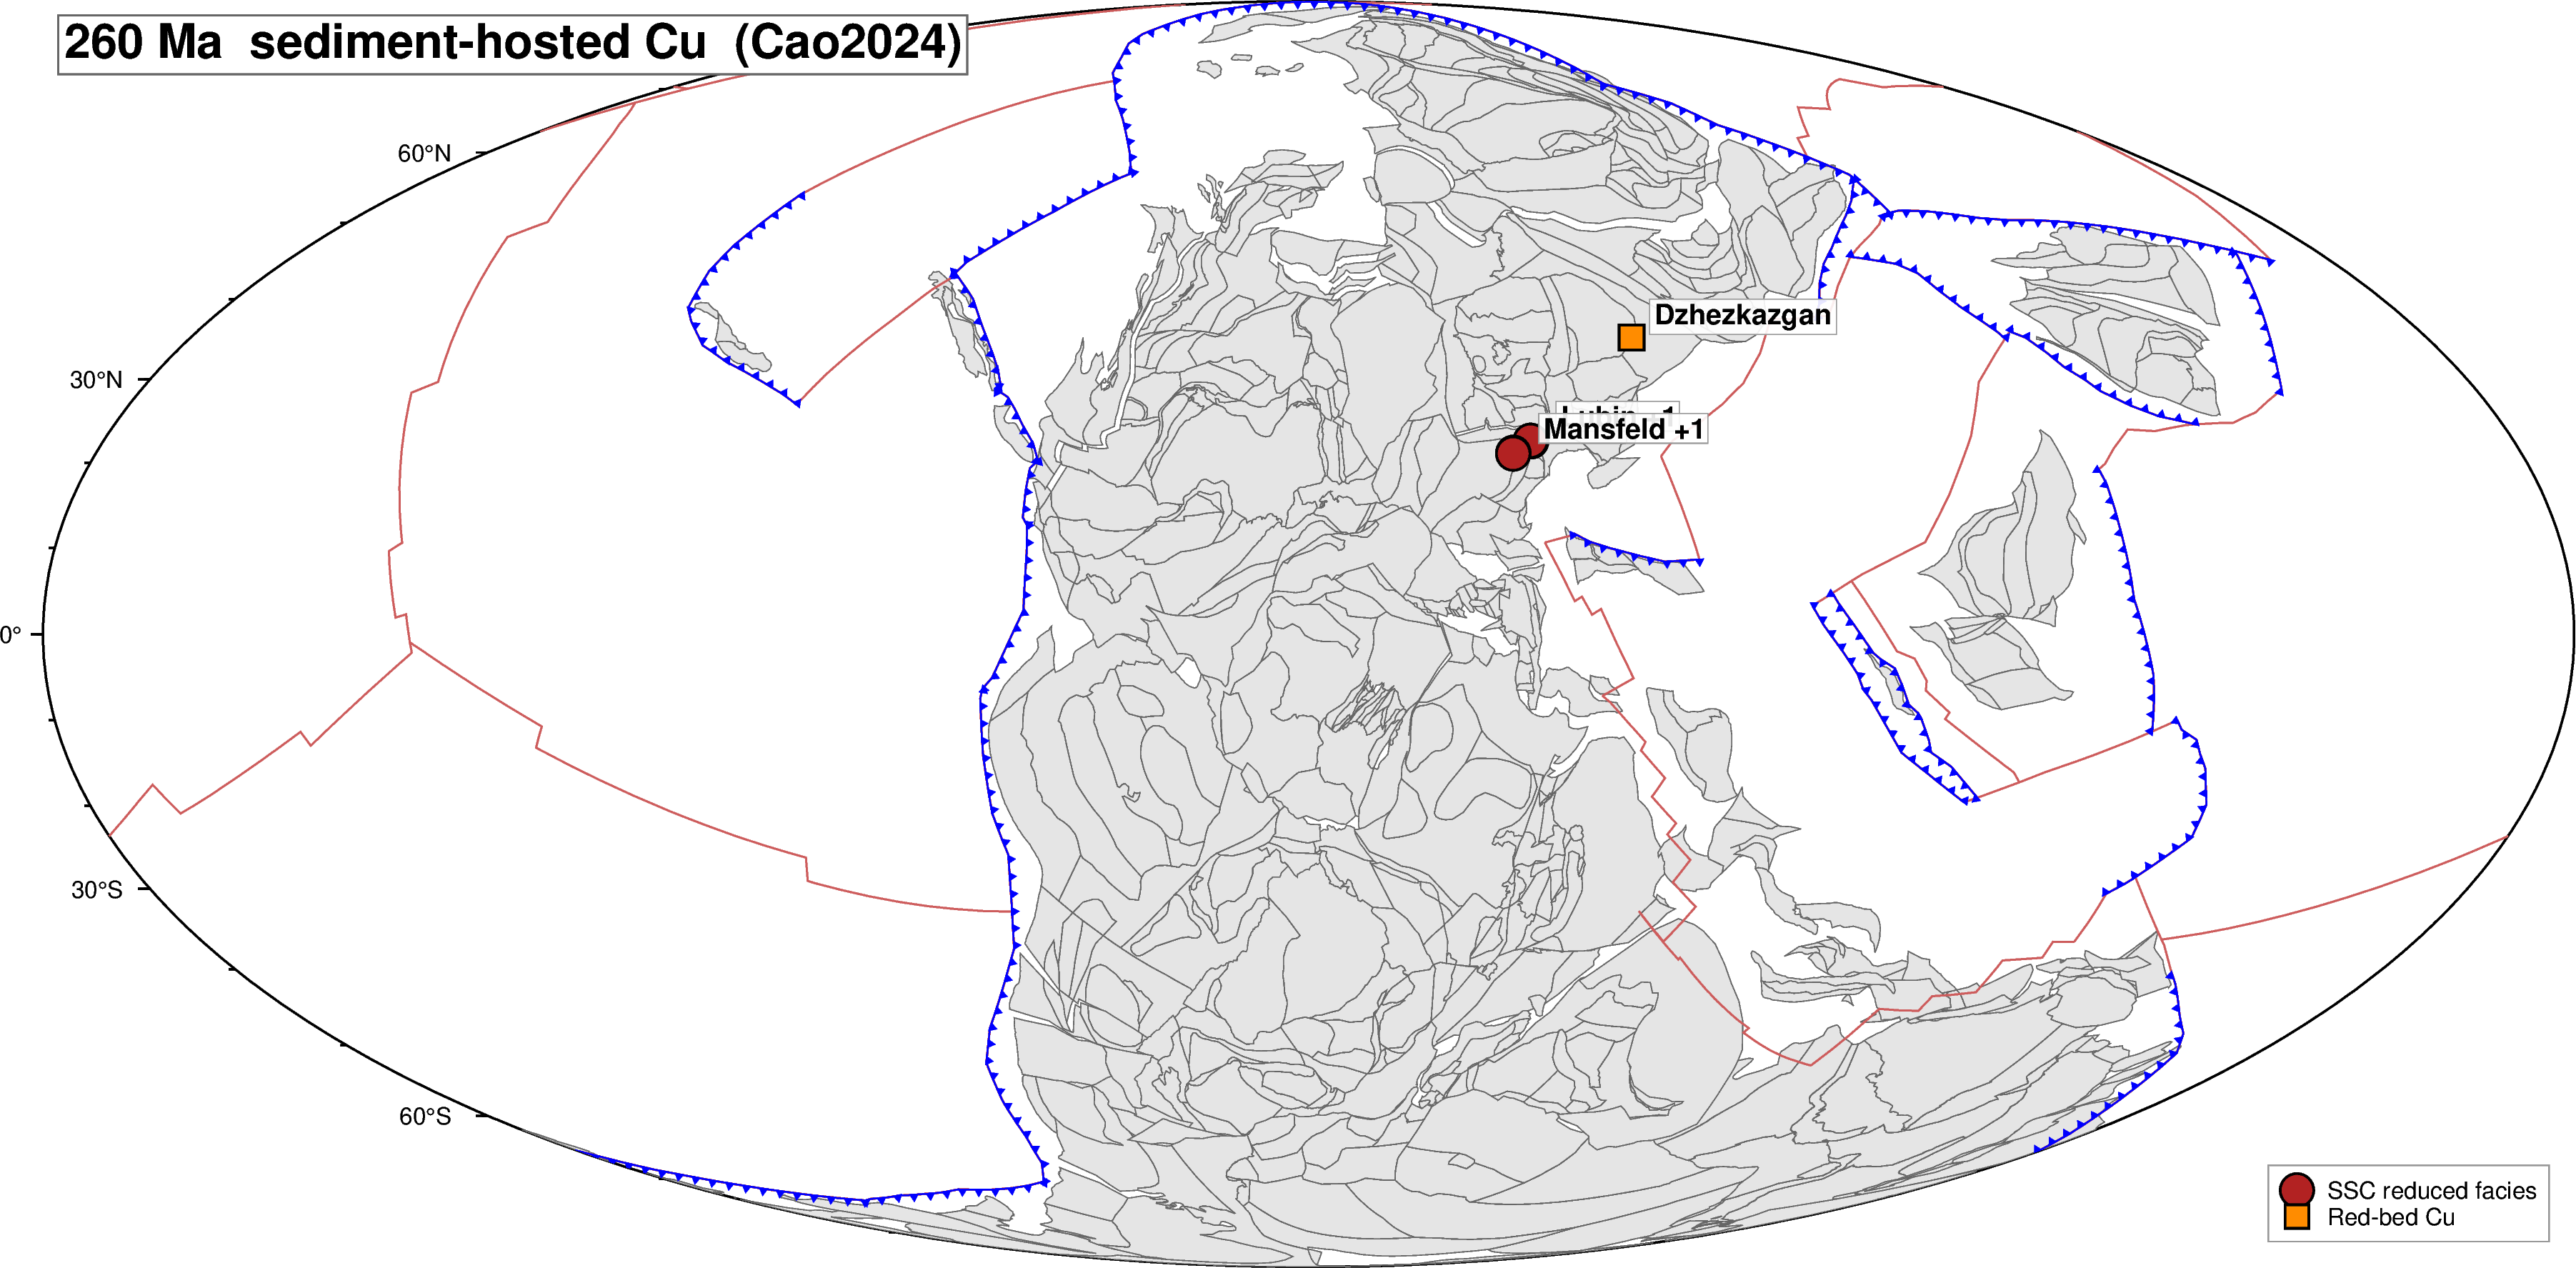

  305 Ma  window 205-405 Ma  -> 5 deposits (['Red-bed Cu', 'SSC reduced facies'])


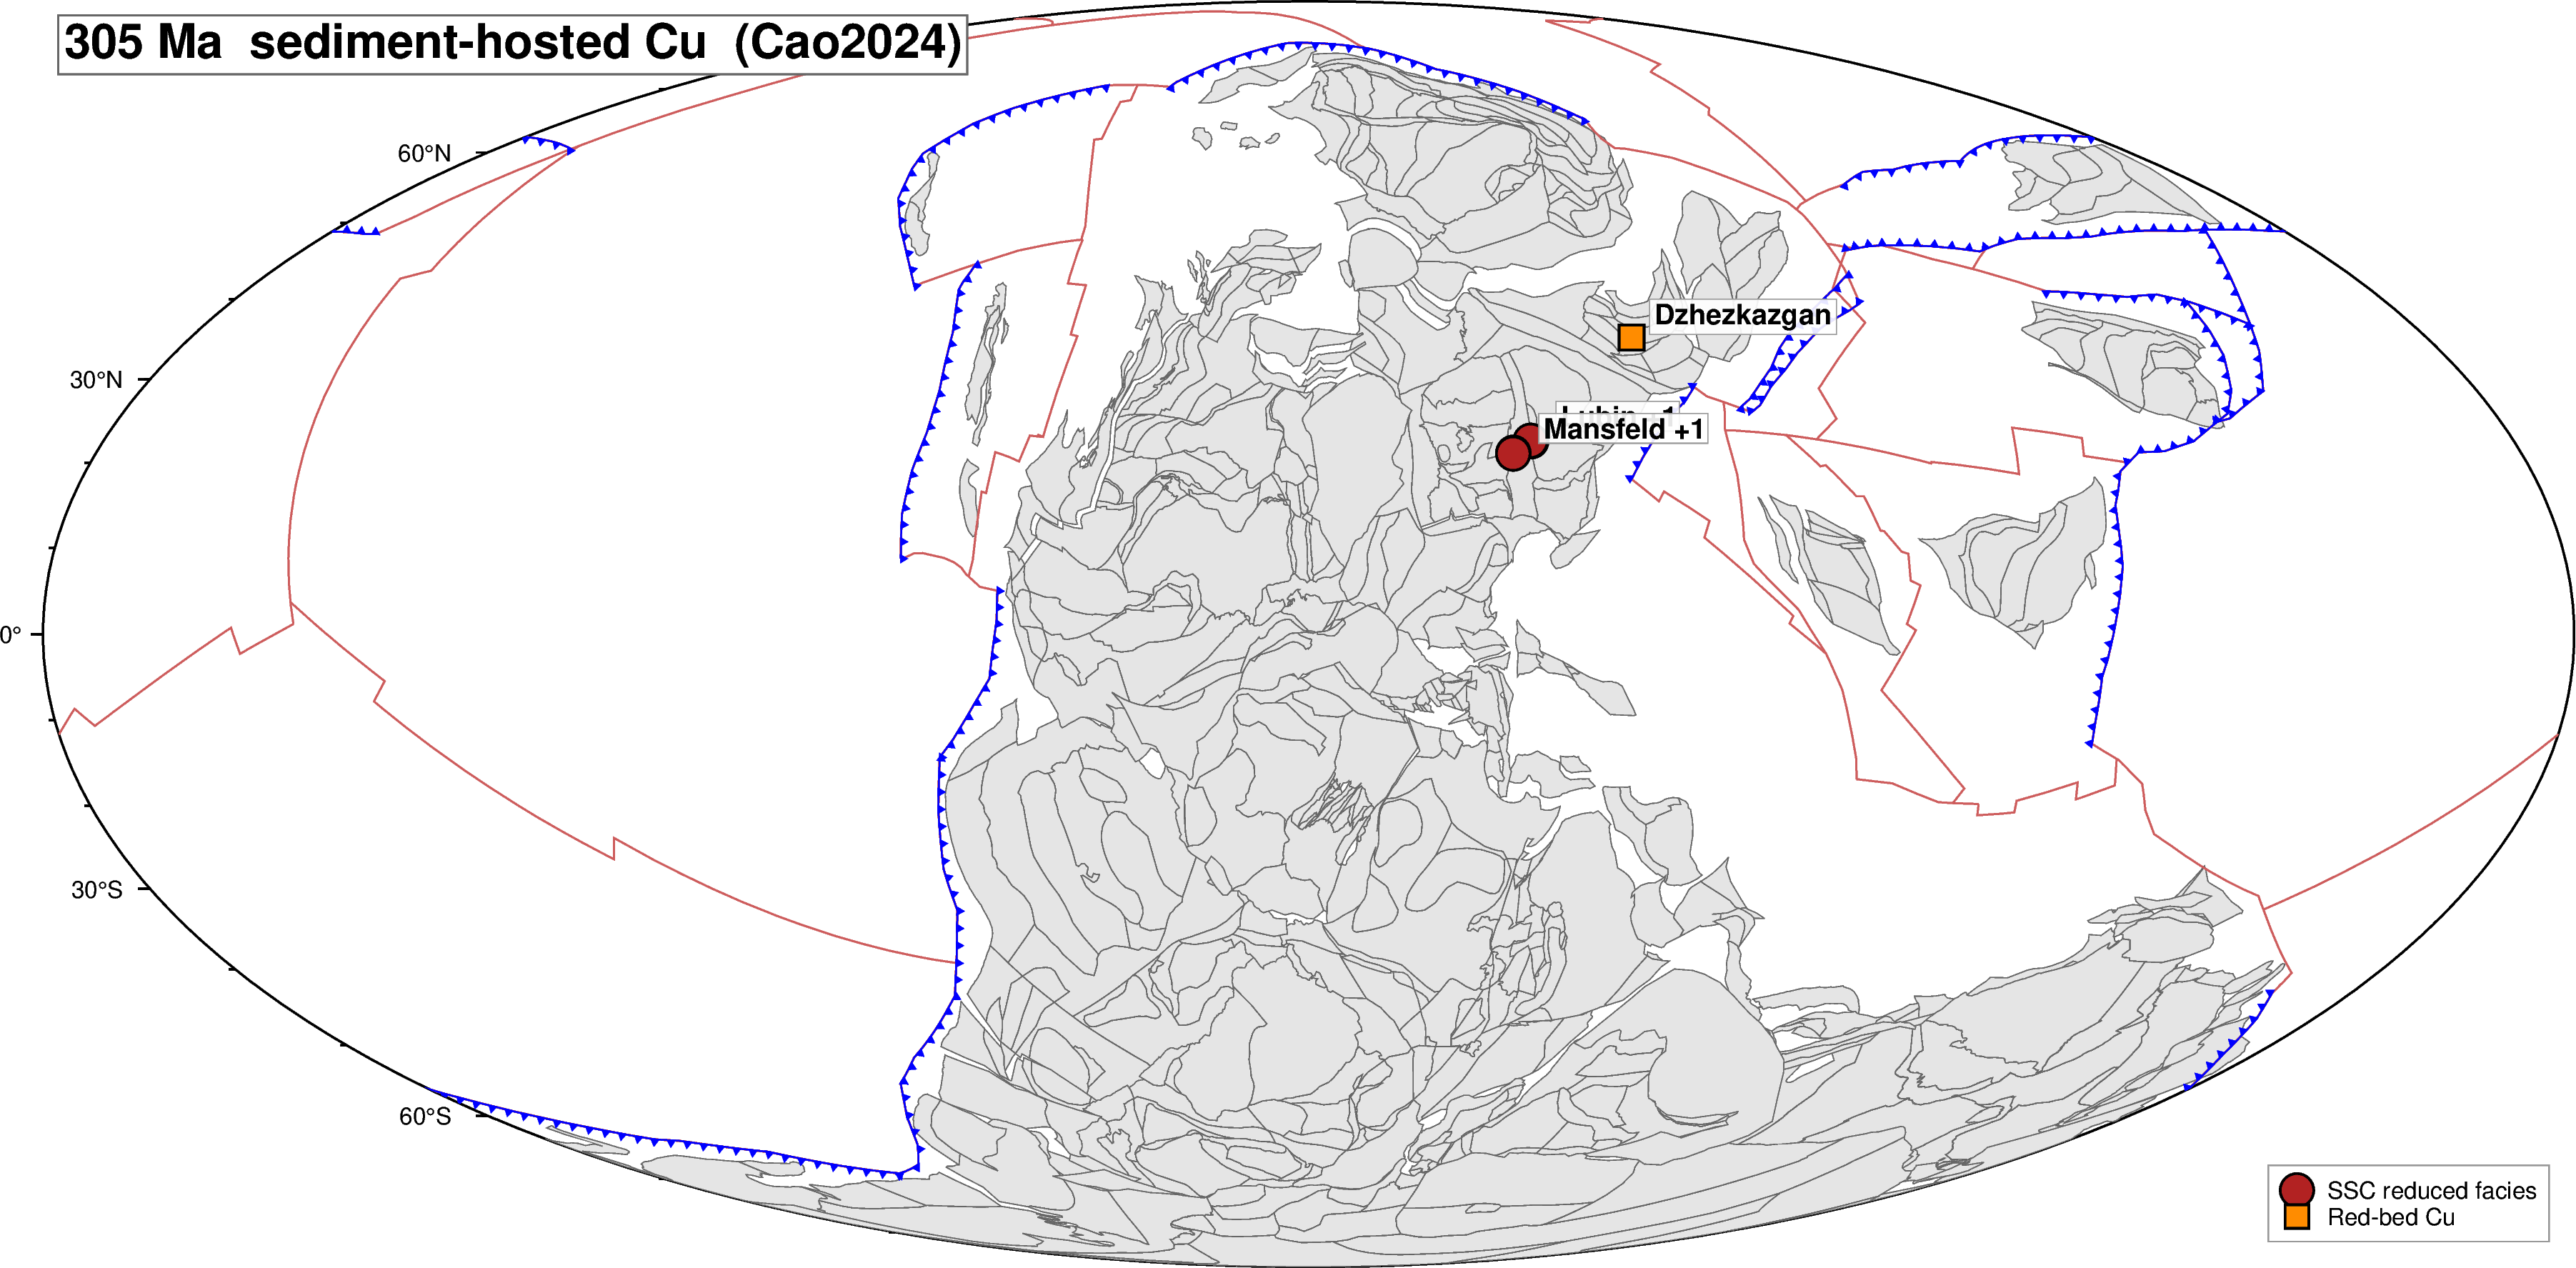

  880 Ma  window 780-980 Ma  -> 6 deposits (['SSC reduced facies'])


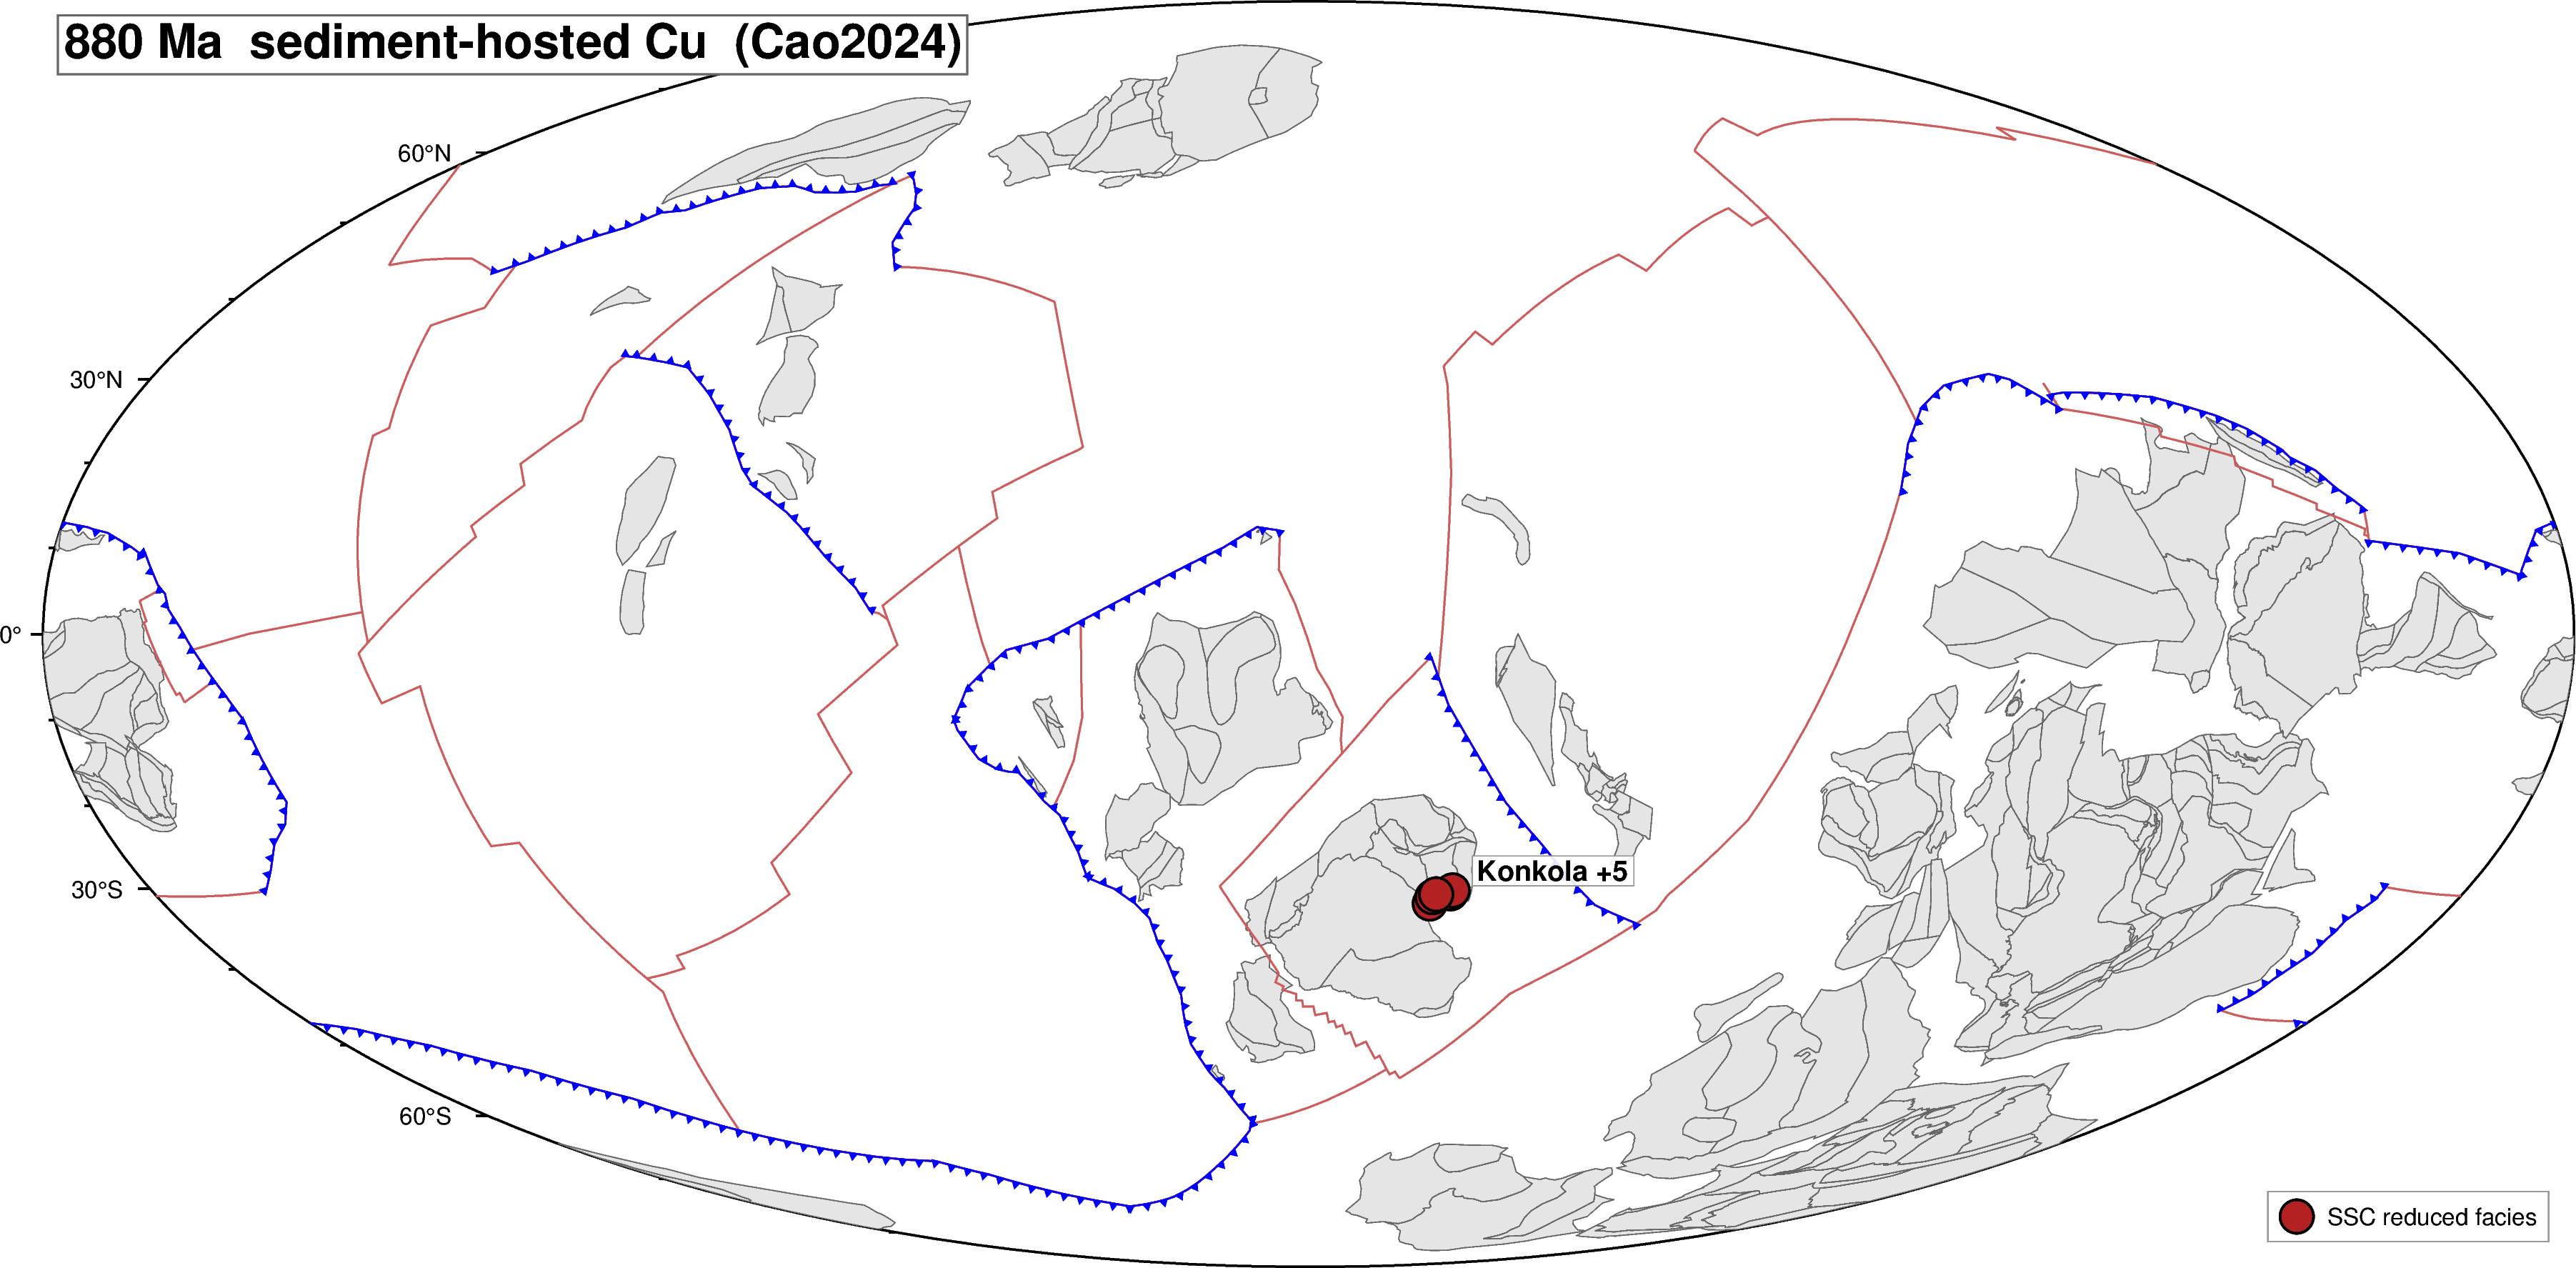

  1075 Ma  window 975-1175 Ma  -> 3 deposits (['IOCG', 'Native Cu (volcanic)', 'SSC reduced facies'])


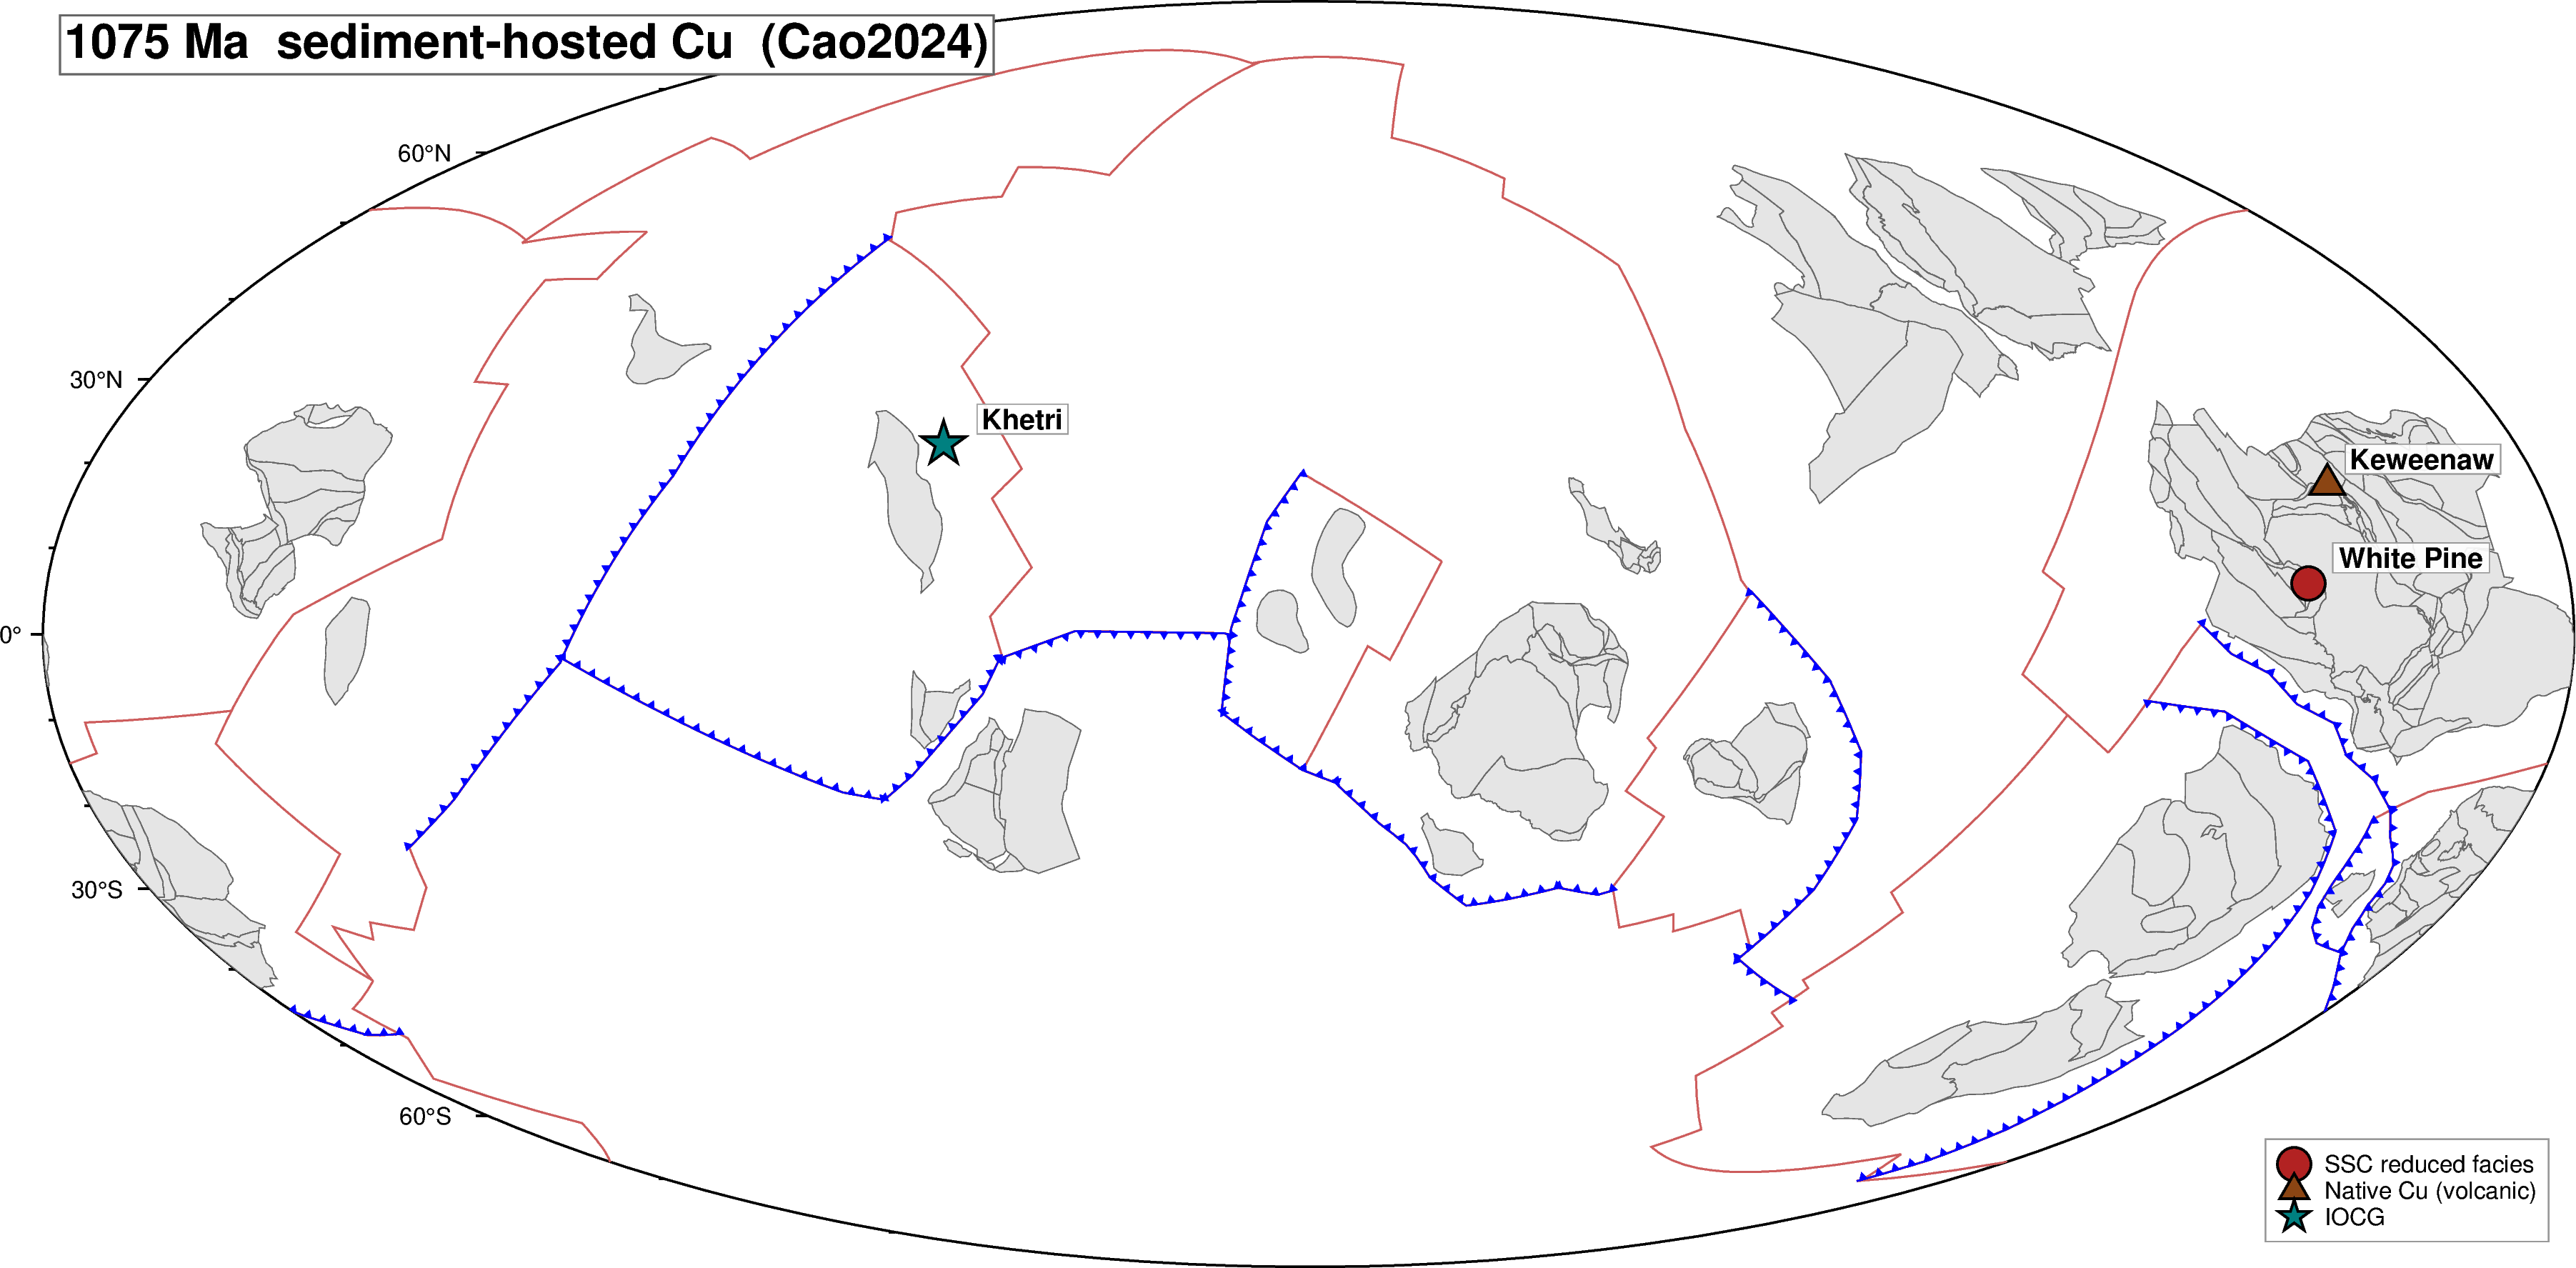

  1660 Ma  window 1560-1760 Ma  -> 2 deposits (['Mt Isa-style'])


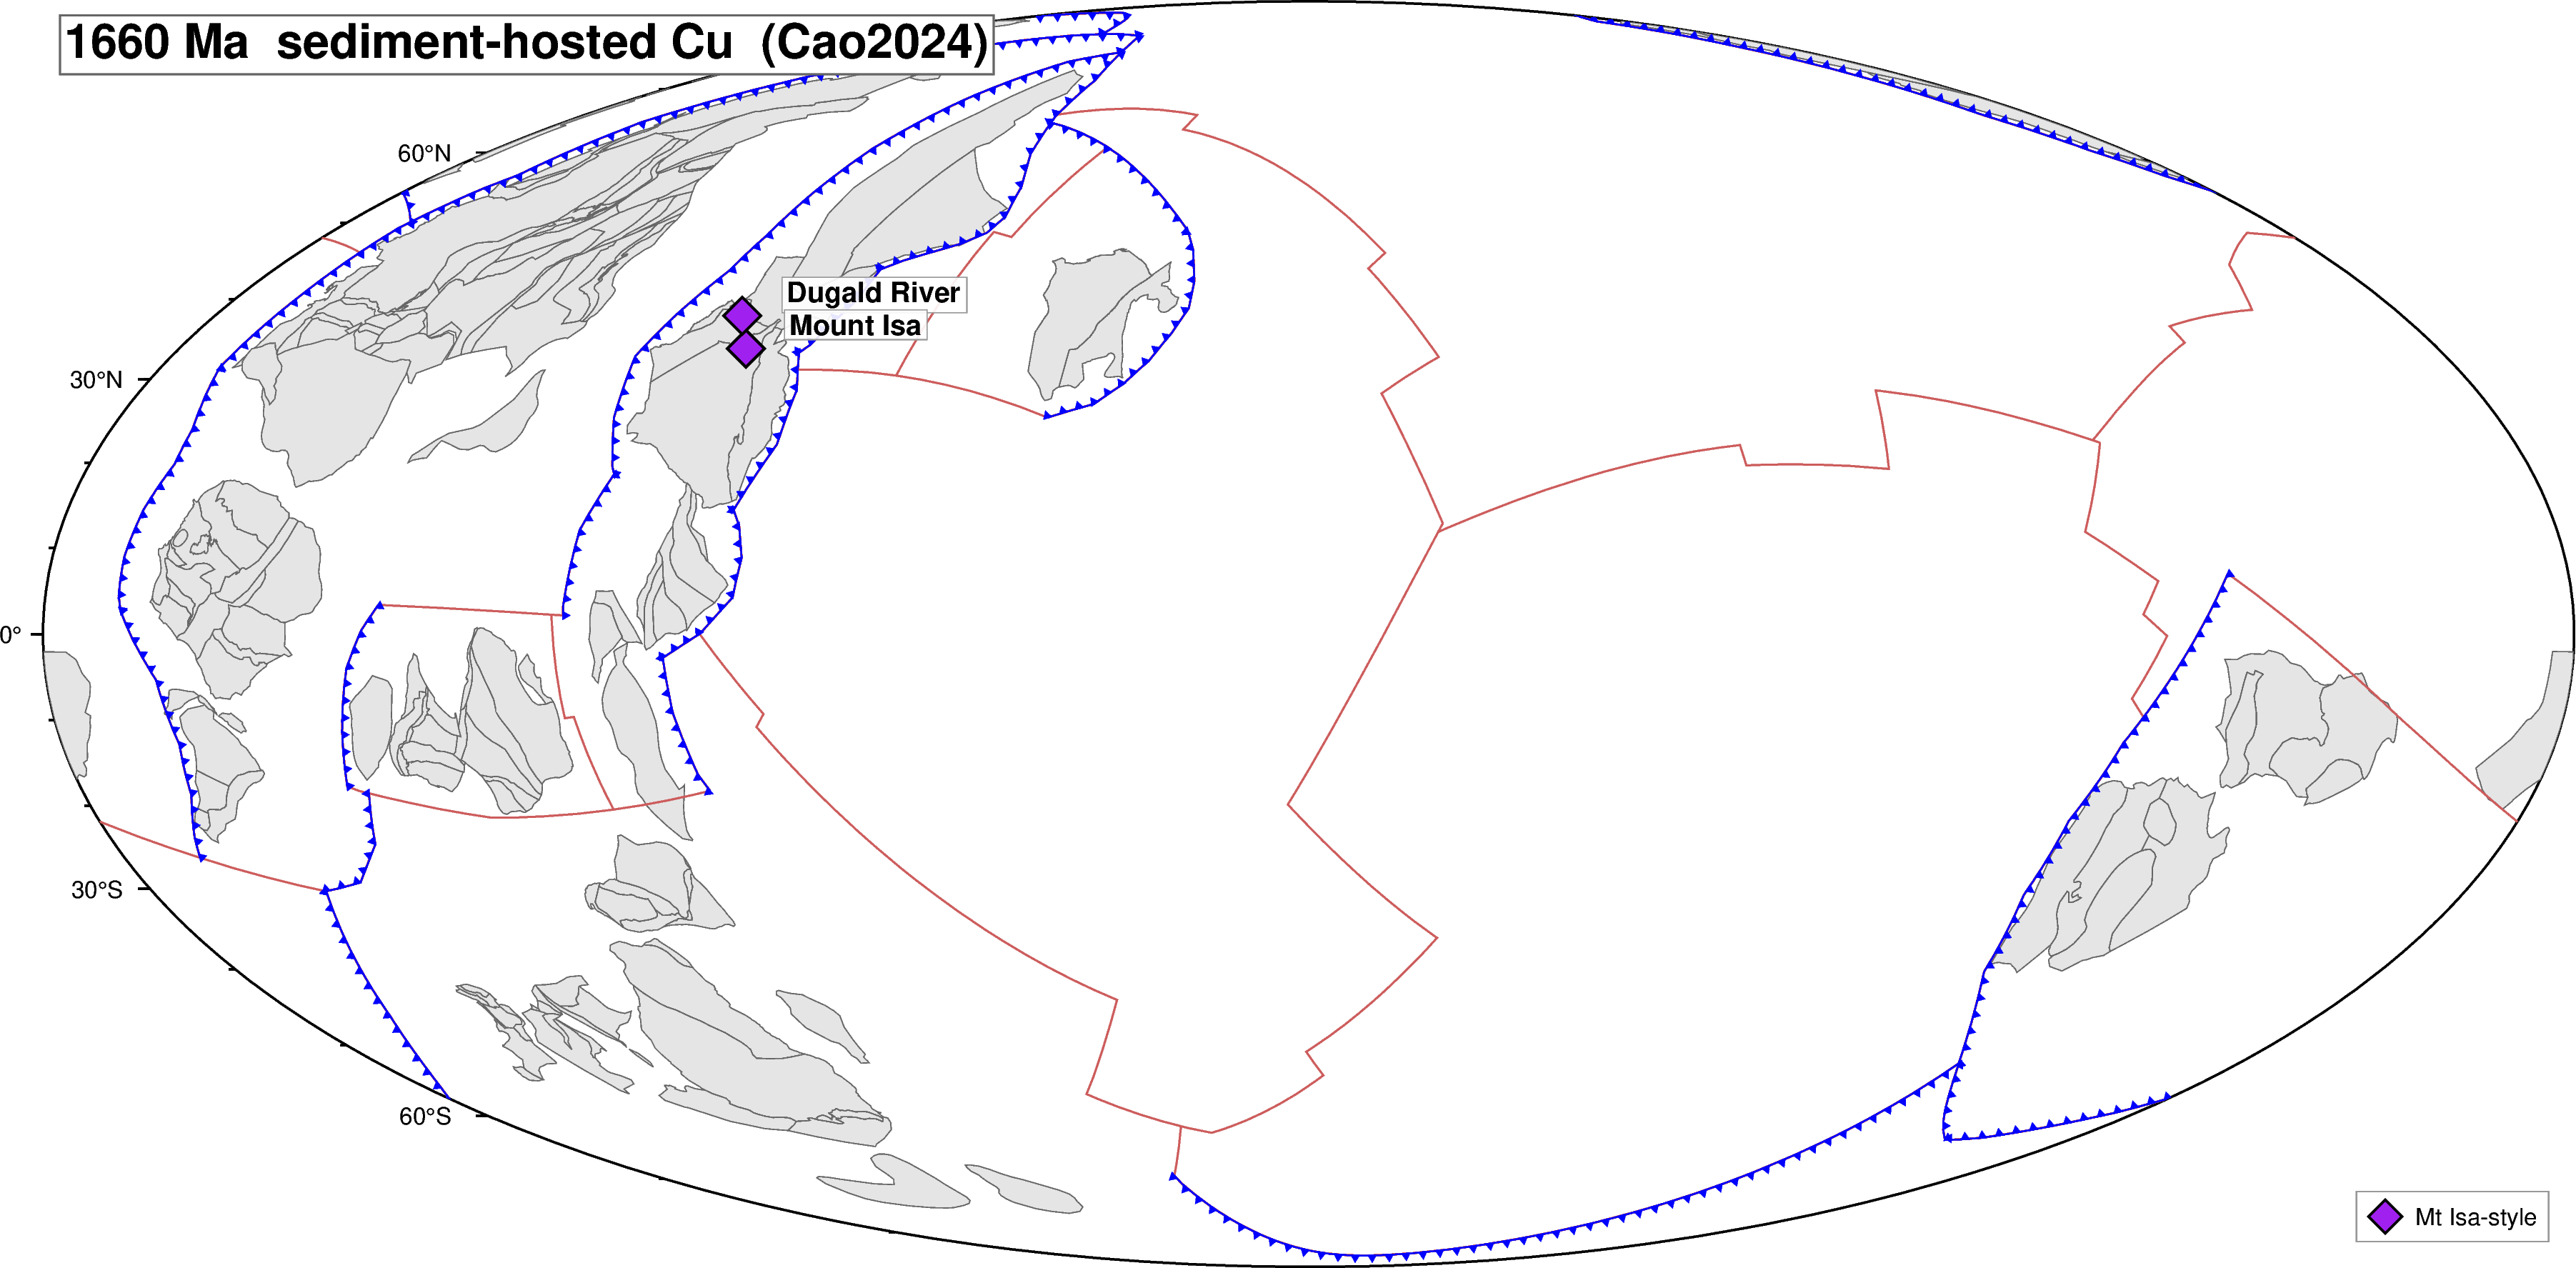

  1800 Ma  window 1700-1900 Ma  -> 1 deposits (['IOCG'])


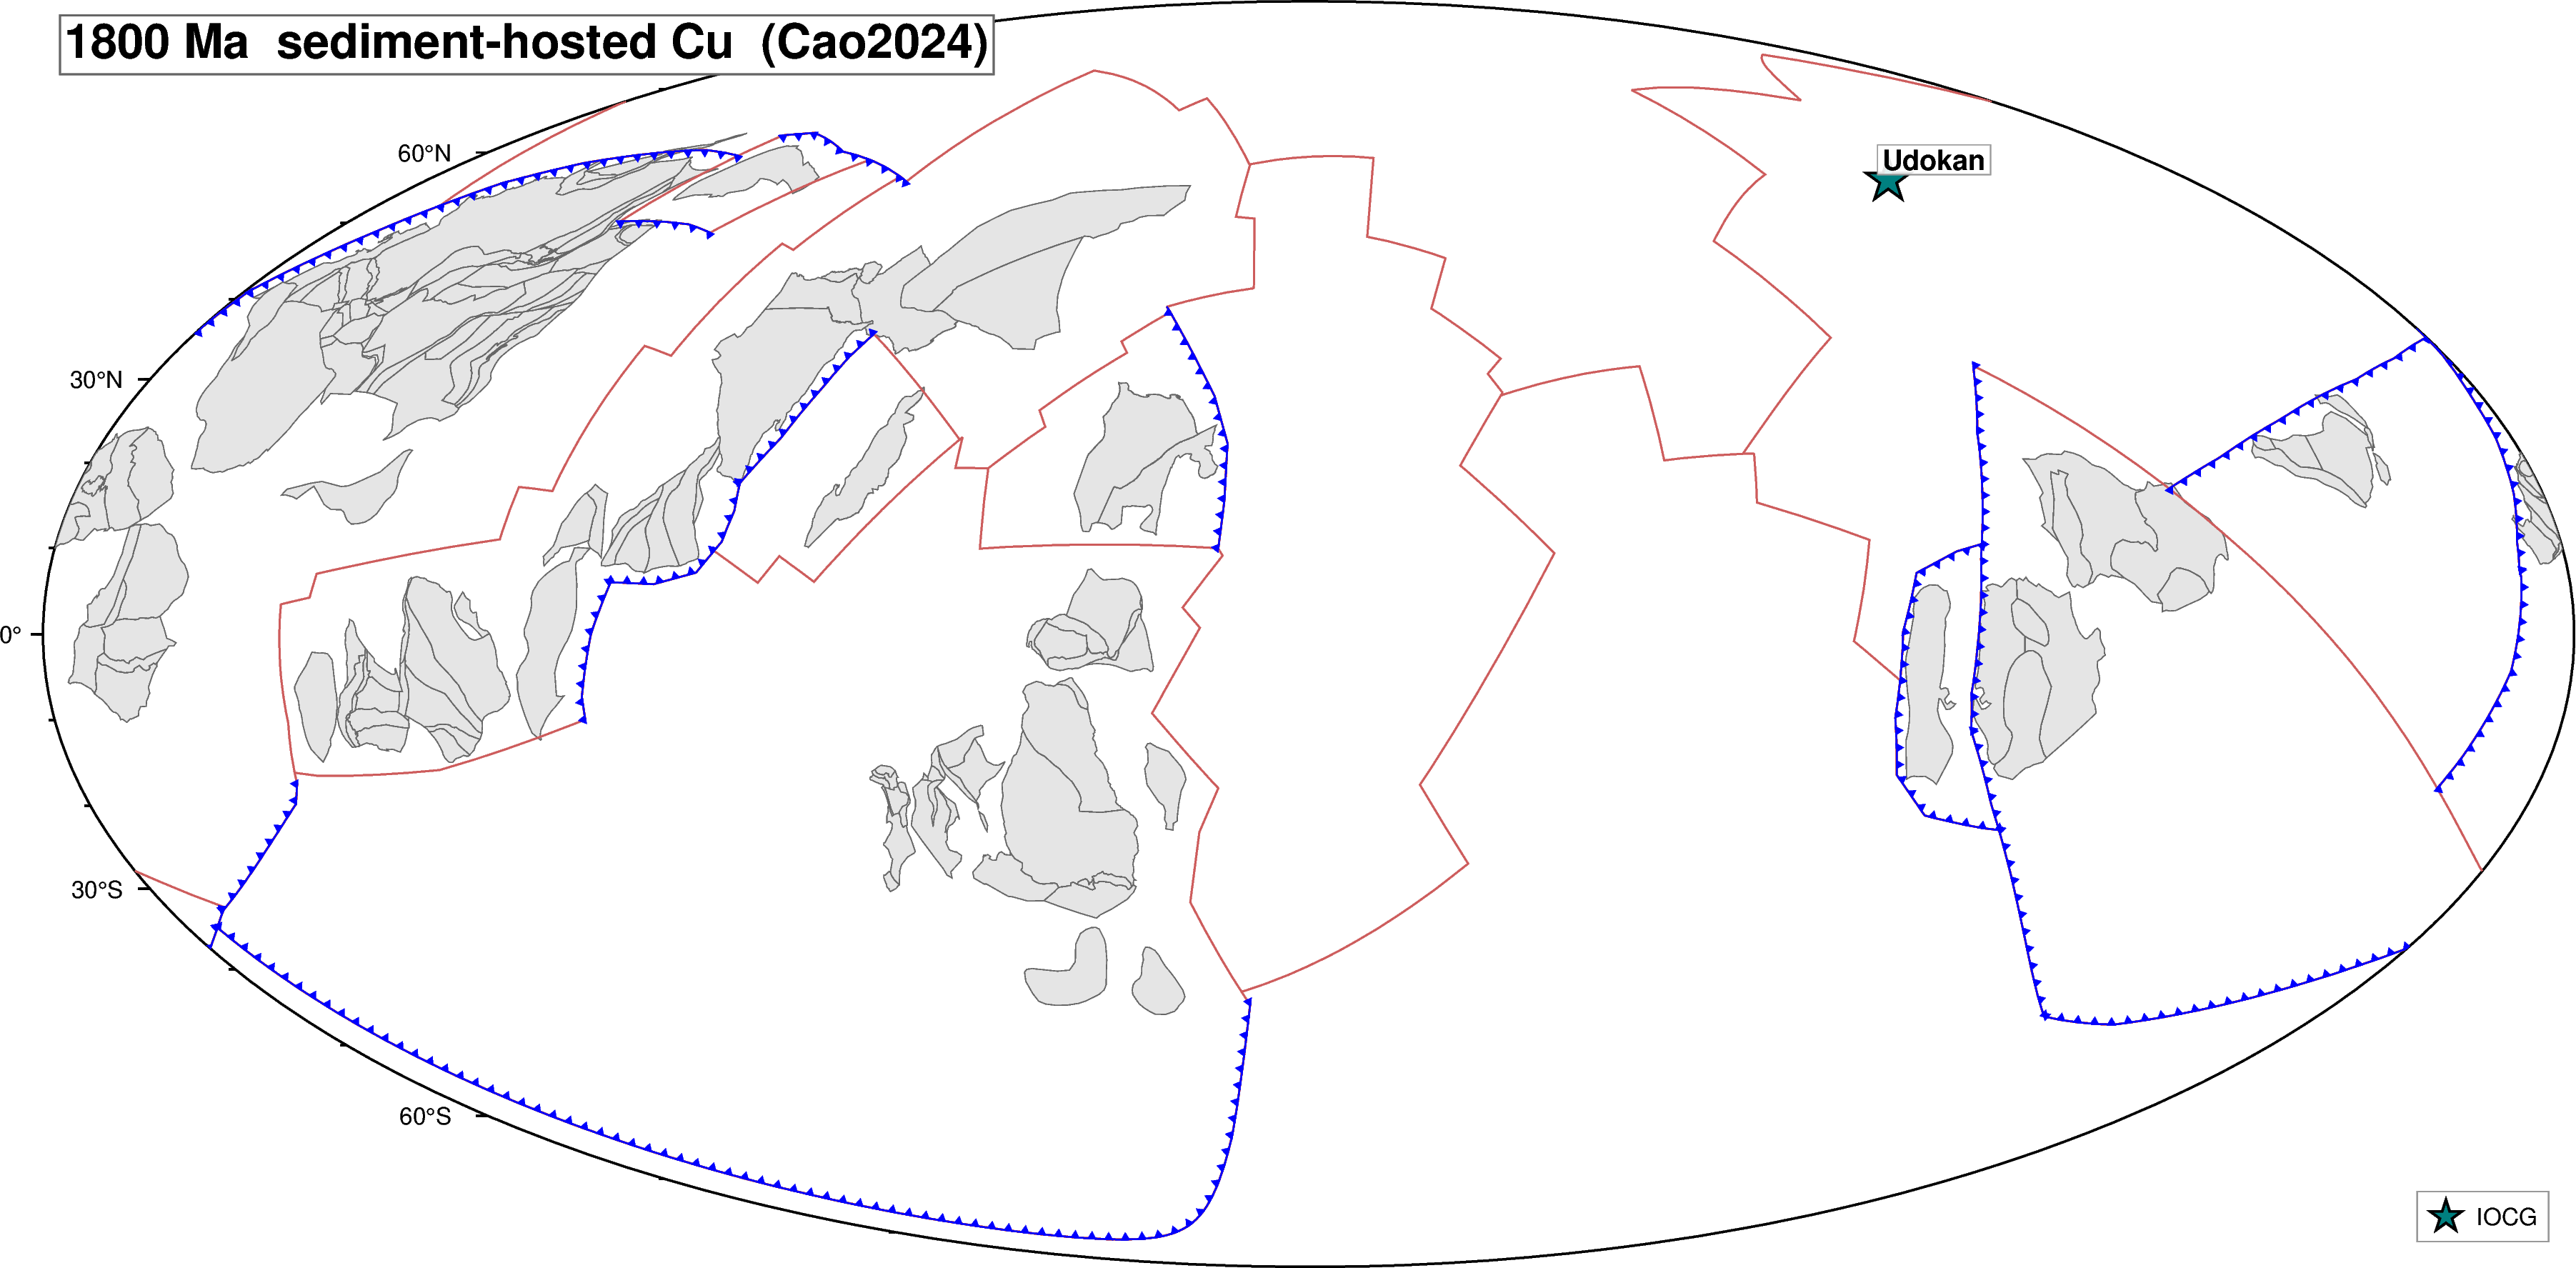

In [15]:
# Cell 4 — render: per-snapshot map, deposits grouped by TYPE
# (different symbols + colors for SSC reduced facies / Red-bed / Native-Cu
# volcanic / Mt Isa-style / IOCG), wide time window so every contemporary
# deposit is on the map (not just the most-densely-clustered ones).
engine = gplately.PygmtPlotEngine()

# --- assign each deposit a TYPE (sediment-hosted Cu sub-class) ---
DEPOSIT_TYPES = {
    # Kupferschiefer-style SSC reduced facies
    "Mansfeld":         "SSC reduced facies",
    "Sangerhausen":     "SSC reduced facies",
    "Polkowice":        "SSC reduced facies",
    "Lubin":            "SSC reduced facies",
    # African Copperbelt SSC reduced facies
    "Konkola":          "SSC reduced facies",
    "Tenke-Fungurume":  "SSC reduced facies",
    "Kolwezi":          "SSC reduced facies",
    "Mufulira":         "SSC reduced facies",
    "Nchanga":          "SSC reduced facies",
    "Mutanda":          "SSC reduced facies",
    # Midcontinent SSC reduced facies
    "White Pine":       "SSC reduced facies",
    # Red-bed sandstone-hosted Cu
    "Corocoro":         "Red-bed Cu",
    "Dzhezkazgan":      "Red-bed Cu",
    # Volcanic-redbed / native Cu
    "Keweenaw":         "Native Cu (volcanic)",
    # Mt Isa-style sediment-hosted Cu (and Pb-Zn-Cu)
    "Mount Isa":        "Mt Isa-style",
    "Dugald River":     "Mt Isa-style",
    # Iron-oxide-Cu-Au association
    "Khetri":           "IOCG",
    "Udokan":           "IOCG",
}
dep["deposit_type"] = dep["name"].map(DEPOSIT_TYPES).fillna("Other")

# style = (pygmt-style string, fill colour); appears in order in the legend.
TYPE_STYLE = [
    ("SSC reduced facies",   "c0.40c", "firebrick"),
    ("Red-bed Cu",           "s0.42c", "darkorange"),
    ("Native Cu (volcanic)", "t0.48c", "saddlebrown"),
    ("Mt Isa-style",         "d0.44c", "purple"),
    ("IOCG",                 "a0.55c", "#008080"),    # teal hex (GMT does not recognise the colour name)
    ("Other",                "c0.32c", "gray50"),
]

# Wide time window so every contemporary deposit is plotted on the
# snapshot map, not just the ones at the exact snapshot age.
TIME_WINDOW_MA = 100.0

# Per-set human-readable headline so each plot block reads as a distinct
# scientific snapshot, not just another row in a grid.
SET_HEADLINES = {
    30.0:   "SET 1 — Bolivian Corocoro (~30 Ma)",
    260.0:  "SET 2 — Permian Kupferschiefer + Russian Cu basins (~260 Ma)",
    305.0:  "SET 3 — Dzhezkazgan Cu (Carboniferous–Permian transition, ~305 Ma)",
    880.0:  "SET 4 — African Copperbelt + global Neoproterozoic Cu (~880 Ma)",
    1075.0: "SET 5 — North American Midcontinent Rift Cu (~1075 Ma)",
    1660.0: "SET 6 — Mt Isa-style Australian Cu (~1660 Ma)",
    1800.0: "SET 7 — Udokan Cu (Russian Paleoproterozoic, ~1800 Ma)",
}

for t in SNAPSHOT_TIMES:
    # Per-set headline banner — printed before each figure so the
    # plot sets in the notebook output read as distinctly labelled
    # scientific snapshots rather than as a generic grid.
    display(HTML(f'<div style="margin-top:1.2cm; padding:0.4em 0.8em; '
                  f'background:#f0f4f9; border-left:5px solid #4a6fa5; '
                  f'font-size:14pt; font-weight:bold; '
                  f'font-family:Helvetica,Arial,sans-serif;">'
                  f'{SET_HEADLINES.get(t, f"~{t:.0f} Ma")}'
                  f'</div>'))
    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(), time=float(t))
    window = dep[(dep.age_ma >= t - TIME_WINDOW_MA) &
                 (dep.age_ma <= t + TIME_WINDOW_MA)]
    print(f"  {t:.0f} Ma  window {t - TIME_WINDOW_MA:.0f}-{t + TIME_WINDOW_MA:.0f} Ma  "
          f"-> {len(window)} deposits ({sorted(window['deposit_type'].unique())})")

    fig = pygmt.Figure()
    # Larger projection (W0/30c) for legible deposit symbols
    fig.basemap(region="d", projection="W0/30c", frame=["af"])
    engine.plot_geo_data_frame(fig, gplot.get_continents(),
                               fill="gray90", pen="0.3p,gray40")
    engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                               pen="0.6p,indianred")
    # Subduction-zone direction overlay (optional — skip silently if the
    # model has no resolved subduction at this age)
    try:
        (_tl, _tr) = gplot.get_subduction_direction()
        engine.plot_subduction_zones(fig, _tl, _tr, color="blue")
    except Exception:
        pass

    # Plot deposits grouped by type — each type gets its own symbol +
    # colour. The `label=` parameter wires each group into the pyGMT
    # legend automatically.
    for type_name, style, fill_col in TYPE_STYLE:
        sub = window[window["deposit_type"] == type_name]
        if not len(sub): continue
        # The +S0.4c after the legend label sets the legend swatch size
        fig.plot(x=sub["paleo_lon"], y=sub["paleo_lat"],
                 style=style, fill=fill_col, pen="0.8p,black",
                 label=f"{type_name}+S0.4c")

    if len(window):
        fig.legend(position="JBR+jBR+o0.3c", box="+gwhite+p0.5p,gray60")

    # Spatial-bin labels: one name per 8 deg x 5 deg paleo-position bin,
    # with "+N" suffix when the bin contains multiple deposits. Keeps the
    # major district names (Kolwezi / Mansfeld / Mount Isa / Keweenaw /
    # Udokan / ...) on the map without overlapping labels in clusters.
    BIN_LON, BIN_LAT = 8.0, 5.0
    bins = {}
    for _, r in window.iterrows():
        bx = int(np.floor(r["paleo_lon"] / BIN_LON))
        by = int(np.floor(r["paleo_lat"] / BIN_LAT))
        bins.setdefault((bx, by), []).append(r)
    for (_, members) in sorted(bins.items(),
                               key=lambda kv: (-np.mean([m["paleo_lat"] for m in kv[1]]),
                                                np.mean([m["paleo_lon"] for m in kv[1]]))):
        clon = float(np.mean([m["paleo_lon"] for m in members]))
        clat = float(np.mean([m["paleo_lat"] for m in members]))
        label = members[0]["name"]
        if len(members) > 1:
            label += f" +{len(members) - 1}"
        fig.text(text=label,
                 x=clon + 5.0, y=clat + 3.0,
                 font="9.5p,Helvetica-Bold,black",
                 justify="LM",
                 fill="white@10",
                 pen="0.3p,gray60",
                 clearance="0.08c/0.05c")

    fig.text(text=f"{t:.0f} Ma  sediment-hosted Cu  ({MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="16p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=1500)
    display(HTML('<div style="height:2cm"></div>'))   # big gap between sets


## What the figures show

One paleo-Earth panel per snapshot age in `SNAPSHOT_TIMES`. Each dot is one sediment-hosted Cu district, sized large enough to be visible at world-projection scale, colour-coded by present-day host country (Zambia/DRC Copperbelt in firebrick, Polish Kupferschiefer in royal blue, Australian Mt Isa-style basins in saddlebrown, etc.). Districts are filtered to a ±25 Myr window around each snapshot age so the figure shows roughly contemporaneous deposits.

**Labels.** District names are placed once per 8° × 5° spatial bin to prevent overlap on cluster-rich panels. When several districts fall in the same bin (typical for the Copperbelt or for closely-spaced Russian/Kazakh basins), the label reads `"FirstName +N"` to signal the cluster size without rendering N overlapping names. Each label is wrapped in a thin white halo to stay legible against the topology backbone.

**Reading the maps.** Sediment-hosted Cu districts cluster in stable cratonic interiors and along passive margins at the time of host-formation deposition. Their paleo-distance to a contemporaneous trench is typically large compared to porphyry-Cu deposits (which sit within ~500 km of a trench) — that contrast is the principal qualitative observation. For a quantitative kinematic-envelope analysis of porphyry-Cu deposits specifically, see T45.


## Extend this

- **Animate.** Loop `SNAPSHOT_TIMES` across 0-1000 Ma in 50 Myr steps and stitch the frames with `pygmt.movie` or external ffmpeg to produce a moving paleo-distribution. Sediment-hosted Cu districts pulse on and off as their host formations cross the snapshot window.
- **Swap continents.** The bundled deposit list emphasises Zambia/DRC, Poland/Germany, Russia/Kazakhstan, USA/Bolivia, India, and Australia. Adapt `COUNTRY_COL` to highlight a different region (e.g. the SW Pacific arcs covered by T44, or the Andean margin covered by T45 / T12).
- **Cross-reference with paleo-Earth fields.** Overlay reconstructed paleo-elevation (Scotese-Wright), paleo-precipitation (HadCM3 or PALEO-PGEM), or paleo-evaporite extent (Boucot Köppen, see T37) to test whether the deposit population sits inside or outside the expected geochemical environment for sediment-hosted Cu mineralisation.
- **Quantitative paleo-distance to ridge / trench.** A full kinematic-envelope analysis (paleo-distance to nearest contemporaneous trench, convergence rate at closest trench, etc.) is implemented for porphyry-Cu deposits in T45 — porting that workflow to this dataset would let you compare the kinematic-envelope of sediment-hosted Cu against porphyry-Cu directly.
